# Run CNMFe on a cutout (interactive)

Pick a spatial sub-region and/or a time window of an existing movie, run the
full extraction on just that cutout, then map the results back onto the full
field of view / timeline.

**You provide:** a `(T, H, W)` zarr movie (raw or already motion-corrected) and
an output folder. **You choose:** the cutout, with sliders (Y / X / time) and an
optional ROI mask.

How it works: the cutout is set on `CNMFeParams`
(`temporal_crop` / `spatial_crop` / `spatial_mask_path`) and applied **once at
ingestion, before motion correction**, so everything downstream runs on the
crop (`model.dims` / trace length = the cutout). `model.place_in_full_fov()`
maps footprints/traces back to the original FOV/timeline for overlay.

> Spatial-crop-before-MC means MC can't pull in content from outside the crop —
> minor edge artifacts within ~`max_shift` px of the border. Leave a small
> margin around your ROI.

## 1. Config

In [1]:
%matplotlib inline
import sys
import time
from dataclasses import replace
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Make the project importable when running the notebook from anywhere.
PROJECT_ROOT = Path('/home/fs539/code/simpler_cnmfe')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from cnmfe.io import open_zarr
from cnmfe.pipeline import CNMFe, CNMFeParams

# --- EDIT ME -----------------------------------------------------------------
MOVIE_ZARR = Path('/media/server/archive/projects/2023_intercontext/ToneComparison/data/1_preprocessed/20260520_m0010798_wt_1051/miniscope_video/mc.zarr')        # (T, H, W) zarr: raw or mc
OUTPUT_DIR = Path('/home/fs539/code/simpler_cnmfe/tmp/cutout_analysis')
DO_MC      = False     # True if MOVIE_ZARR is raw; False if already corrected
# -----------------------------------------------------------------------------

# Extraction parameters in NATIVE units. The cutout fields (temporal_crop /
# spatial_crop / spatial_mask_path) are added from your selection in section 5.
PARAMS = CNMFeParams(
    sigma=3.0, min_corr=0.8, min_pnr=8.0,
    n_iter_main=1, n_iter_temporal=2,
    merge_thr_corr=0.85, spatial_max_thr=0.1,
    max_shift=(20, 20), mc_gSig_filt=7, mc_n_iter=1,
    n_jobs=-1, decay_time_ms=180, g_prior_weight=0.7, spatial_max_iter = 20000
)

# --- TRY ME (component shape tuning) -----------------------------------------
# Defaults above (spatial_max_thr=0.1, min_pnr=10) gave 152 halo-dominated
# components tiling the FOV. The replace() below tightens five shape-related
# knobs together; comment it out to fall back to the bare defaults. Re-run
# the diagnostic in section 7c after re-extraction to see what changed.
# PARAMS = replace(
#     PARAMS,
#     spatial_max_thr=0.25,                  # was 0.1:  cut halo at 25% of peak
#     spatial_circular_max_dist_factor=1.2,  # was 1.5:  tighter radial clip
#     min_pnr=15.0,                          # was 10:   fewer ghost seeds post-detrend
#     merge_thr_corr=0.75,                   # was 0.85: merge duplicates more aggressively
#     global_bg_rank=1,                      # was 0:    absorb vignetting-coupled drift
# )
# -----------------------------------------------------------------------------

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('movie :', MOVIE_ZARR)
print('output:', OUTPUT_DIR, '|  DO_MC =', DO_MC)
assert MOVIE_ZARR.exists(), f'movie zarr not found: {MOVIE_ZARR}'

movie : /media/server/archive/projects/2023_intercontext/ToneComparison/data/1_preprocessed/20260520_m0010798_wt_1051/miniscope_video/mc.zarr
output: /home/fs539/code/simpler_cnmfe/tmp/cutout_analysis |  DO_MC = False


## 2. Load movie + reference views

Stream a mean projection (for the spatial picker) and a per-frame spatial-mean
activity trace (for the temporal picker). The full movie is never loaded.

movie: (37398, 300, 300)  dtype=float32  chunks=(1000, 300, 300)
mean image: (300, 300) | activity samples: (2078,)


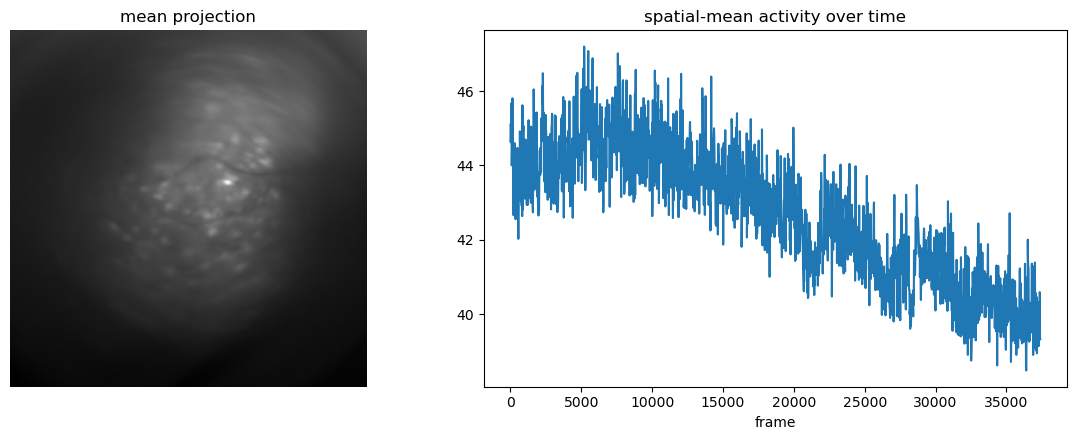

In [2]:
z = open_zarr(MOVIE_ZARR)
T, H, W = z.shape
print(f'movie: {z.shape}  dtype={z.dtype}  chunks={z.chunks}')

chunk_t = z.chunks[0]

def mean_proj_and_activity(arr, max_pts=2000, chunk_t=chunk_t):
    """Single chunk-aligned pass: streamed mean projection + per-frame spatial
    mean on a strided sample. Reads each zarr chunk exactly once, then strides
    within the in-RAM batch for the activity samples.
    """
    T = arr.shape[0]
    step = max(1, T // max_pts)
    acc = np.zeros(arr.shape[1:], dtype=np.float64)
    idx_list, vals_list = [], []
    for s in range(0, T, chunk_t):
        e = min(s + chunk_t, T)
        batch = np.asarray(arr[s:e], dtype=np.float32)   # one chunk decompress
        acc += batch.sum(0, dtype=np.float64)
        local_offset = (-s) % step                       # keep global stride
        if local_offset < e - s:
            local_idx = np.arange(local_offset, e - s, step)
            idx_list.append(s + local_idx)
            vals_list.append(batch[local_idx].reshape(local_idx.size, -1).mean(axis=1))
    mean_img = (acc / T).astype(np.float32)
    t_idx = np.concatenate(idx_list) if idx_list else np.array([], dtype=int)
    activity = (np.concatenate(vals_list).astype(np.float32)
                if vals_list else np.array([], dtype=np.float32))
    return mean_img, t_idx, activity

mean_img, t_idx, activity = mean_proj_and_activity(z)
print('mean image:', mean_img.shape, '| activity samples:', activity.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].imshow(mean_img, cmap='gray'); ax[0].set_title('mean projection'); ax[0].axis('off')
ax[1].plot(t_idx, activity); ax[1].set_title('spatial-mean activity over time')
ax[1].set_xlabel('frame'); plt.tight_layout(); plt.show()

## 2b. Per-pixel temporal detrend (optional preprocessing)

When the activity trace in section 2 shows a clear slow ramp / decay
(photobleach, LED warm-up, focus drift), greedy init in section 6 will
seed ghost components on top of that drift and the extracted footprints
look diffuse. The trace-level `ar_detrend_order` / `temporal_detrend_order`
knobs can't fix this because they run **after** init.

`detrend_movie` subtracts a per-pixel rolling lower-percentile baseline
along time (window = `DETREND_WINDOW_S * frame_rate_hz` frames). The lower
percentile is robust to bright transients (the window is dominated by
inter-event baseline), so real calcium spikes survive but slow drifts get
flattened. Output is written to `mc_detrended.zarr` next to `mc.zarr` and
becomes the input to sections 3–8 when enabled. Idempotent — delete the
zarr to re-run.

**Trade-off:** the detrend also removes any genuinely population-wide slow
signal. Leave `DETREND_WINDOW_S = None` to skip the step entirely when
traces look clean.

Skipping detrend; /media/server/archive/projects/2023_intercontext/ToneComparison/data/1_preprocessed/20260520_m0010798_wt_1051/miniscope_video/mc_detrended.zarr already exists.
detrend wall time: 24.7s  ->  /media/server/archive/projects/2023_intercontext/ToneComparison/data/1_preprocessed/20260520_m0010798_wt_1051/miniscope_video/mc_detrended.zarr


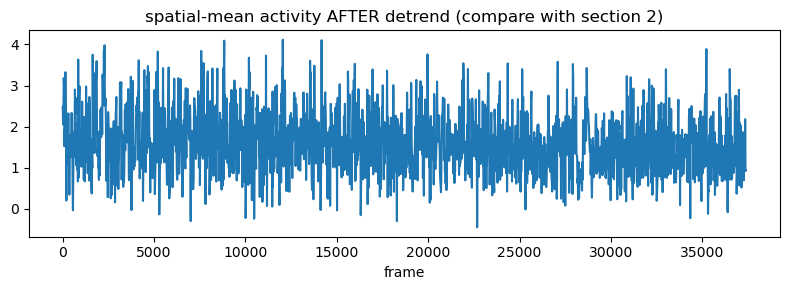

In [3]:
# --- EDIT ME -----------------------------------------------------------------
DETREND_WINDOW_S   = 30.0   # rolling window in seconds; None = skip detrend
DETREND_PERCENTILE = 10.0   # lower-percentile baseline (robust to spikes)
FRAME_RATE_HZ      = 20.0   # acquisition frame rate (set per-recording)
# -----------------------------------------------------------------------------

if DETREND_WINDOW_S is None:
    print('detrend: SKIPPED (set DETREND_WINDOW_S to enable)')
else:
    from cnmfe.detrend import detrend_movie
    DETRENDED_ZARR = MOVIE_ZARR.parent / 'mc_detrended.zarr'
    t0 = time.time()
    z = detrend_movie(
        MOVIE_ZARR, DETRENDED_ZARR,
        window_s=DETREND_WINDOW_S,
        percentile=DETREND_PERCENTILE,
        frame_rate_hz=FRAME_RATE_HZ,
        n_jobs=-1,
        skip_if_exists=True,
    )
    print(f'detrend wall time: {time.time() - t0:.1f}s  ->  {DETRENDED_ZARR}')
    # Refresh the picker views from the detrended zarr so section 3 reflects
    # the bleach-flattened movie. The full-FOV detrended zarr is also what
    # section 6's fit() will read (cutout sliced from it at ingestion).
    mean_img, t_idx, activity = mean_proj_and_activity(z)
    T, H, W = z.shape
    fig, ax = plt.subplots(1, 1, figsize=(8, 3))
    ax.plot(t_idx, activity)
    ax.set_title('spatial-mean activity AFTER detrend (compare with section 2)')
    ax.set_xlabel('frame'); plt.tight_layout(); plt.show()

## 3. Choose the cutout (interactive)

Drag the **Y**, **X** and **time** range sliders; the preview redraws the crop
rectangle on the mean image and shades the time window. Selection persists into
the cells below.

In [4]:
import ipywidgets as widgets
from IPython.display import display

def _mid(n):
    return (int(n * 0.2), int(n * 0.8))     # default: middle ~60% of the axis

def _full(n):
    return (int(n * 0), int(n * 1))
t_slider = widgets.IntRangeSlider(value=_full(T), min=0, max=T, step=1,
                                  description='time', continuous_update=False,
                                  layout=widgets.Layout(width='95%'))
y_slider = widgets.IntRangeSlider(value=_mid(H), min=0, max=H, step=1,
                                  description='Y (rows)', continuous_update=False,
                                  layout=widgets.Layout(width='95%'))
x_slider = widgets.IntRangeSlider(value=_mid(W), min=0, max=W, step=1,
                                  description='X (cols)', continuous_update=False,
                                  layout=widgets.Layout(width='95%'))

def _preview(t, y, x):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    ax[0].imshow(mean_img, cmap='gray')
    ax[0].add_patch(plt.Rectangle((x[0], y[0]), x[1] - x[0], y[1] - y[0],
                                  ec='r', fc='none', lw=1.5))
    ax[0].set_title(f'crop  Y[{y[0]}:{y[1]}]  X[{x[0]}:{x[1]}]  '
                    f'({y[1]-y[0]}x{x[1]-x[0]})')
    ax[0].axis('off')
    ax[1].plot(t_idx, activity)
    ax[1].axvspan(t[0], t[1], color='r', alpha=0.2)
    ax[1].set_title(f'time [{t[0]}:{t[1]}]  ({t[1]-t[0]} frames)')
    ax[1].set_xlabel('frame')
    plt.tight_layout(); plt.show()

_out = widgets.interactive_output(
    _preview, {'t': t_slider, 'y': y_slider, 'x': x_slider})
display(widgets.VBox([t_slider, y_slider, x_slider]), _out)
print('Adjust the sliders, then run the cells below.')
print('No widgets in your IDE? Set t_slider.value=(t0,t1) (and y_/x_slider) '
      'in a cell, or edit the coords directly in section 5.')

Output()

Adjust the sliders, then run the cells below.
No widgets in your IDE? Set t_slider.value=(t0,t1) (and y_/x_slider) in a cell, or edit the coords directly in section 5.


## 4. Optional ROI mask

Leave `USE_MASK = False` for a plain rectangle. Set it `True` to restrict to a
non-rectangular region — loaded from a `.npy` or derived by thresholding the
mean image. The mask's bounding box (∩ the rectangle) sets the final crop;
pixels inside the box but outside the mask are zeroed.

In [20]:
# Optional ROI mask — restrict to a non-rectangular region inside the crop.
# (Freehand drawing needs ipympl, which isn't installed; we load a .npy or
# threshold the mean image instead.)
USE_MASK   = False
MASK_NPY   = None    # path to a bool .npy of shape (H, W); or None to derive
MASK_PCTILE = 90     # when deriving: keep pixels >= this percentile of the mean

mask_path = None
if USE_MASK:
    (y0, y1), (x0, x1) = y_slider.value, x_slider.value
    if MASK_NPY is not None:
        mask = np.load(MASK_NPY).astype(bool)
        assert mask.shape == (H, W), f'mask {mask.shape} != movie {(H, W)}'
    else:
        thr = float(np.percentile(mean_img[y0:y1, x0:x1], MASK_PCTILE))
        mask = np.zeros((H, W), dtype=bool)
        mask[y0:y1, x0:x1] = mean_img[y0:y1, x0:x1] >= thr
    mask_path = str(OUTPUT_DIR / 'roi_mask.npy')
    np.save(mask_path, mask)
    fig, ax = plt.subplots(1, 1, figsize=(5.5, 5.5))
    ax.imshow(mean_img, cmap='gray')
    ax.imshow(np.ma.masked_where(~mask, mask), cmap='autumn', alpha=0.45)
    ax.set_title(f'ROI mask: {int(mask.sum())} px  ->  {mask_path}'); ax.axis('off')
    plt.tight_layout(); plt.show()
else:
    print('USE_MASK = False  ->  rectangle + time window only')

USE_MASK = False  ->  rectangle + time window only


## 5. Build the cutout parameters

In [21]:
# Read the selection (slider .value persists) and attach the cutout to a copy
# of PARAMS. Edit these directly if the sliders didn't render.
t0, t1 = t_slider.value
y0, y1 = y_slider.value
x0, x1 = x_slider.value

params = replace(
    PARAMS,
    temporal_crop=(t0, t1),
    spatial_crop=(y0, y1, x0, x1),
    spatial_mask_path=mask_path,
    sigma = 3.0,
    min_pnr = 12)
print(f'cutout: T[{t0}:{t1}] ({t1-t0} frames)  Y[{y0}:{y1}] X[{x0}:{x1}] '
      f'({y1-y0}x{x1-x0})  mask={"yes" if mask_path else "no"}')

cutout: T[0:37398] (37398 frames)  Y[38:257] X[37:259] (219x222)  mask=no


In [34]:
#good
params = replace(
    PARAMS,
    temporal_crop=(1000, 5000),
    spatial_crop=(y0, y1, x0, x1),
    spatial_mask_path=mask_path,
    sigma = 3.0,
    min_pnr = 20,
min_corr = 0.9)

### Long-video config — why these drift-control params are here

Running the **full recording** (the cell below, no `temporal_crop`) produced
sprawling, merged footprints ("broken components"), while the short 4000-frame
clip above gave clean cells. A controlled 2x2 (length x thresholds, fixed crop,
full `CNMFe.fit`) showed the sprawl is driven by **recording length, not the
thresholds**:

| config | final footprint npix (median / max) |
|---|---|
| short, 4000 fr, strict 0.9/20 | 86 / 182 |
| short, 4000 fr, loose 0.8/12 | 79 / 198 |
| **long, 37398 fr, strict 0.9/20** | **209 / 360** |
| **long, 37398 fr, loose 0.8/12** | **155 / 368** |

At matched thresholds, going long ~doubles footprint size; at matched length the
thresholds barely move size (they only change the component **count**).

**Mechanism.** Over tens of thousands of frames the slow drift / photobleaching
(~9% over this recording) gives every trace a shared low-frequency trend, so the
temporal traces become collinear and `update_spatial`'s per-pixel LASSO can no
longer separate neighbouring cells -- it smears each footprint across its
neighbours into big merged blobs.

**Fixes applied below (each verified on the long recording):**
- `global_bg_rank=1` -- absorb the shared drift as a rank-1 temporal background,
  de-collinearising the traces. Footprint npix median 209->113; +spatial cleanup
  ->71. (Equivalent alternative: the section-2b temporal detrend.)
- `spatial_max_thr=0.25`, `spatial_circular_max_dist_factor=1.2` -- trim halo
  (tighter footprints -> less overlap -> less cross-talk).
- `merge_thr_corr=0.90`, `merge_centre_dist_factor=1.0` -- **dense-field fix.** The
  earlier 0.75 / 2.0 (meant to fuse drift duplicates) over-merged genuinely
  distinct, co-active neighbours: greedy init found 214 cells but the 0.75 merge
  collapsed them to 109. With drift already handled by `global_bg_rank=1`, the
  gentler 0.90 / 1.0 keeps them -- **K 109 -> 175, footprints even tighter (npix
  median 92 -> 62)**. (~37% of detectable cells still aren't captured: a separate,
  harder dense-field detection limit.)
- `n_iter_main=2` -- **trace purity at high K.** Packing more cells in raises
  footprint overlap, so each cell's `C+YrA` soaks up neighbours' transients
  (cross-talk) and drifts from the clean deconvolved `C` -- even for *strong* cells
  (`corr(C, C+YrA)` strong-cell 0.77 at K=221 -> 0.48 at K=722). A 2nd BCD
  iteration + the tighter footprints above sharpen the demixing and restore it
  (**0.48 -> 0.77 at K~600**), at ~30% more runtime.
- `init_stride=2` -- the auto value is `max(1, T//5000)=7` for this movie, which
  subsamples calcium transients away and under-detects; pin it small.

`min_corr` / `min_pnr` set the component **count**, not footprint shape; in a dense
field prefer `C` over `C + YrA` (the gap is `YrA` cross-talk, not `C` being wrong).

In [ ]:
# LONG video: full recording (no temporal_crop). See the markdown above for WHY
# these params are here (length sprawl + dense-field over-merging + cross-talk).
params = replace(
    PARAMS,
    spatial_crop=(y0, y1, x0, x1),
    spatial_mask_path=mask_path,
    sigma=3.0,
    min_corr=0.8, min_pnr=12,                  # COUNT knob (shape/merge/purity fixed below)
    n_iter_main=2,                             # 2 BCD iters: sharpen demixing -> recovers C vs
                                               #   C+YrA at high K (strong-cell r 0.48->0.77); ~30% slower
    global_bg_rank=1,                          # absorb slow drift -> de-collinearise traces (PRIMARY fix)
    spatial_max_thr=0.25,                      # cut halo at 25% of peak (tighter -> less overlap/cross-talk)
    spatial_circular_max_dist_factor=1.2,      # tighter radial clip
    merge_thr_corr=0.90,                       # was 0.75: 0.75 over-merged dense co-active
                                               #   neighbours (214 init -> 109); 0.90 keeps them (-> ~175)
    merge_centre_dist_factor=1.0,              # was 2.0: don't fuse distinct cells just for sitting <2sigma apart
    init_stride=2,                             # auto = T//5000 = 7 -> under-detects; keep transients
)

## 6. Run extraction on the cutout

The cutout is applied at ingestion (before MC). For a raw movie keep
`DO_MC=True`; for an already-corrected `mc.zarr` set it `False`.

In [38]:
# model.min_corr

In [39]:
t_start = time.time()
model = CNMFe(params).fit(z, do_motion_correction=DO_MC)
print(f'\nextracted {model.A.shape[1]} components in {time.time()-t_start:.1f}s')
print(f'cutout dims = {model.dims}   T = {model.C.shape[1]}')
print(f'recorded cutout meta: {model.cutout}')

Cutout: T[0:37398] H[38:257] W[37:259] -> (37398, 219, 222)
Extraction config: n_jobs=-1 device=cpu T=37398 H=219 W=222 streaming=no (movie materialised in RAM)
Estimating noise...
Running greedy CORR-PNR initialization (init_stride=2, T_init=18699; corrpnr_stride=9, T_corrpnr=2077)...
  Found 173 initial components.
Fitting ring-model background (radius=10.5px, tsub=5)...
Fitting rank-1 global background b_f · f(t) (initial)...
Refinement iteration 1/1...
  Pre-merging duplicate seeds...
  111 components (33 pre-merged).
  Updating spatial footprints...
  Updating temporal traces...
  Merging correlated components...
  109 components (2 merged).
Final temporal update...
Auto-evaluation: 109/109 accepted (flagged 0: 0 fail pixel_count<3, 0 fail snr_amp<3.0). All components retained; filter via model.accepted_mask.
Done. Extracted 109 neurons.
Stage timings (total 809.1s):
  noise estimation            1.1s     0%
  greedy init               179.1s    22%
  compute_W                  15

## 7. Inspect (crop coordinates)

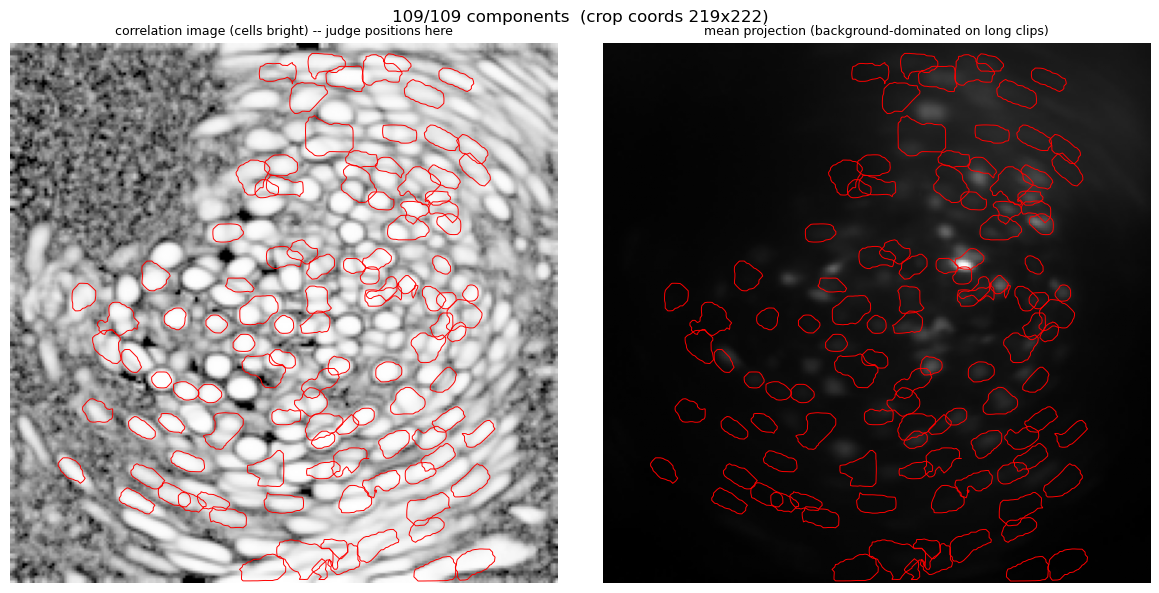

In [46]:
# Footprint contours over an ACTIVITY (correlation) image -- neurons are bright
# there. On long recordings the mean projection is dominated by static
# background/vasculature (cells are transient -> dim in the mean), so footprints
# can look "off the bright spots" even when they sit on the real cells. Judge
# positions on the correlation panel; the mean is shown for context.
from cnmfe.preprocess import correlation_pnr

Kc = model.A.shape[1]
hc, wc = model.dims
A_c = np.asarray(model.A.todense()).reshape(hc, wc, Kc)
acc = model.accepted_mask if model.accepted_mask is not None else np.ones(Kc, bool)
y0, y1, x0, x1 = model.cutout['bbox']
t0c, t1c = (model.cutout.get('t_range') or (0, z.shape[0]))
crop_mean = mean_img[y0:y1, x0:x1]

# correlation image of the cutout (strided sample, capped ~4000 frames)
_st = max(1, (t1c - t0c) // 4000)
_samp = np.asarray(z[t0c:t1c:_st, y0:y1, x0:x1], dtype=np.float32)
cn, _pnr = correlation_pnr(_samp, sigma=params.sigma, center_psf=True, n_jobs=-1)



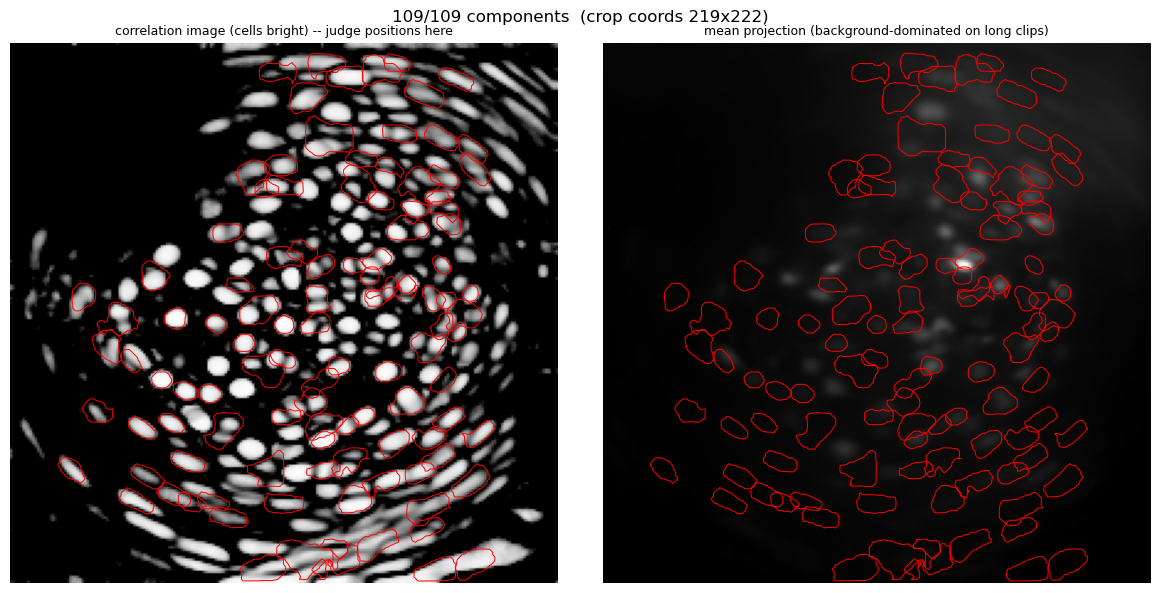

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, img, ttl in [(axes[0], cn,        'correlation image (cells bright) -- judge positions here'),
                     (axes[1], crop_mean, 'mean projection (background-dominated on long clips)')]:
    ax.imshow(img, cmap='gray', vmin = PARAMS.__getattribute__("min_corr"))
    for k in range(Kc):
        fp = A_c[..., k]
        if fp.max() <= 0:
            continue
        ax.contour(fp, [fp.max() * 0.3], colors='red' if acc[k] else '0.6', linewidths=0.7)
    ax.set_title(ttl, fontsize=9); ax.axis('off')
fig.suptitle(f'{int(acc.sum())}/{Kc} components  (crop coords {hc}x{wc})')
plt.tight_layout(); plt.show()

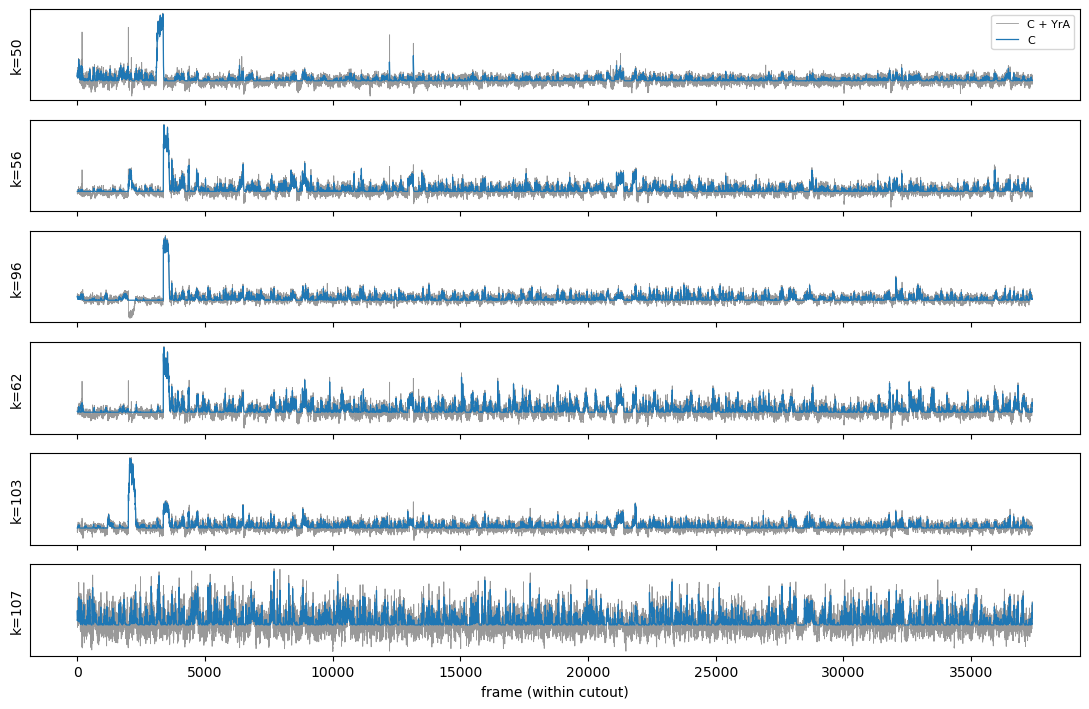

In [41]:
n = min(6, Kc)
if n == 0:
    print('no components to plot')
else:
    pool = np.where(acc)[0]
    pool = pool if pool.size else np.arange(Kc)
    order = pool[np.argsort(-model.C[pool].max(1))][:n]
    fig, axes = plt.subplots(n, 1, figsize=(11, 1.2 * n), sharex=True)
    axes = np.atleast_1d(axes)
    for axi, k in zip(axes, order):
        axi.plot(model.C[k] + model.YrA[k], color='0.6', lw=0.6, label='C + YrA')
        axi.plot(model.C[k], color='C0', lw=0.9, label='C')
        axi.set_ylabel(f'k={k}'); axi.set_yticks([])
    axes[0].legend(loc='upper right', fontsize=8)
    axes[-1].set_xlabel('frame (within cutout)')
    plt.tight_layout(); plt.show()

## 7c. Per-component diagnostic panel

The contour plot in section 7 collapses each footprint to a single 30 %-of-peak
line, so over-large halo-dominated footprints just look like "another blob".
This cell shows the **actual** spatial structure of the top-N components as
small heatmaps centered on each component's centroid, plus three histograms
(area / peak / eccentricity) and a printed median area.

What to look for:
- **Roundish, soma-sized blobs filling the crop window** → healthy. Median
  area near `π·(2σ)² ≈ 314 px` for σ=5.
- **Soft, fuzzy, fill-the-window-edge-to-edge blobs** → halo dominated.
  `spatial_max_thr` is too low and/or background isn't catching residual drift.
- **Streaky / oval / multi-bright-spot panels** → vasculature contamination or
  failed merges. Tighten `spatial_circular_max_dist_factor` and/or lower
  `merge_thr_corr`.
- **Many tiny / fragmented panels** → raise `min_pixel`.

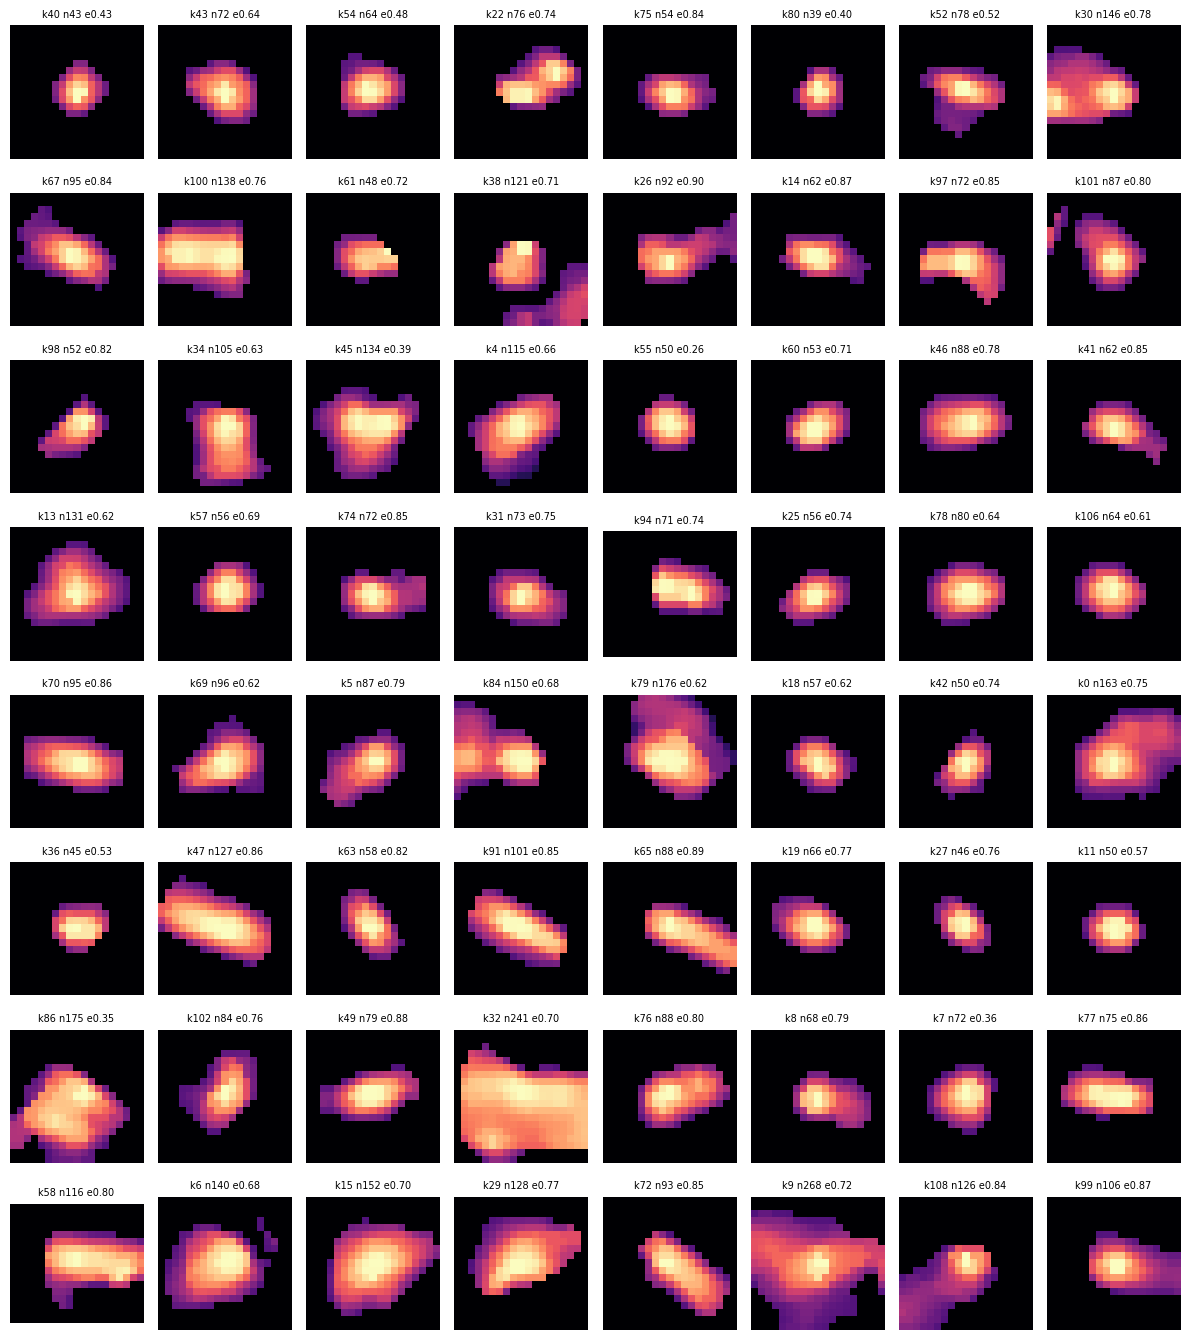

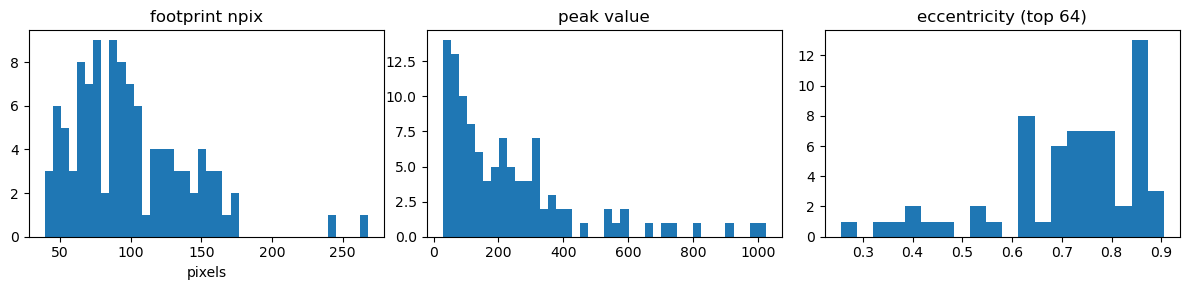

median footprint area: 92 px  (expected ~113 px for 2σ disk; σ=3.0)
mean / max area: 100 / 268 px
#components: 109


In [42]:
N_SHOW  = 64                       # top-N by peak; raise to inspect more
CROP_R  = int(3 * params.sigma)    # half-side of per-component crop window

Kc = model.A.shape[1]
hc, wc = model.dims
A_dense = np.asarray(model.A.todense()).reshape(hc, wc, Kc)

peaks = A_dense.reshape(-1, Kc).max(0)
order = np.argsort(-peaks)[:min(N_SHOW, Kc)]

from cnmfe._utils import footprint_center
stats = []
for k in order:
    fp = A_dense[..., k]
    nz = fp > 0
    npix = int(nz.sum())
    if npix == 0:
        stats.append((k, 0, 0.0, 0.0, (hc // 2, wc // 2))); continue
    # argmax centre (the algorithm's own `footprint_center`) so the soma is
    # centred in the crop; binary-mask COM drifts off haloed/multi-peak cells.
    cy, cx = footprint_center(fp)
    ys, xs = np.where(nz)
    if ys.size >= 2:
        cov = np.cov(np.vstack([ys, xs]))
        eig = np.linalg.eigvalsh(cov)
        ecc = float(np.sqrt(max(0.0, 1 - eig.min() / max(eig.max(), 1e-9))))
    else:
        ecc = 0.0
    stats.append((k, npix, float(fp.max()), ecc, (cy, cx)))

ncols = 8
nrows = int(np.ceil(len(stats) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(1.5 * ncols, 1.7 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, (k, npix, pk, ecc, (cy, cx)) in zip(axes, stats):
    y0 = max(0, cy - CROP_R); y1 = min(hc, cy + CROP_R + 1)
    x0 = max(0, cx - CROP_R); x1 = min(wc, cx + CROP_R + 1)
    ax.imshow(A_dense[y0:y1, x0:x1, k], cmap='magma',
              vmin=0, vmax=max(pk, 1e-9))
    ax.set_title(f'k{k} n{npix} e{ecc:.2f}', fontsize=7)
    ax.axis('off')
for ax in axes[len(stats):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

# Whole-population summaries
all_npix = np.array([(A_dense[..., k] > 0).sum() for k in range(Kc)])
all_pk   = peaks

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].hist(all_npix, bins=40); ax[0].set_title('footprint npix'); ax[0].set_xlabel('pixels')
ax[1].hist(all_pk,   bins=40); ax[1].set_title('peak value')
ax[2].hist([s[3] for s in stats], bins=20); ax[2].set_title(f'eccentricity (top {len(stats)})')
plt.tight_layout(); plt.show()

expected_npix = int(np.pi * (2 * params.sigma) ** 2)   # ~2σ disk
print(f'median footprint area: {int(np.median(all_npix))} px  '
      f'(expected ~{expected_npix} px for 2σ disk; σ={params.sigma})')
print(f'mean / max area: {all_npix.mean():.0f} / {all_npix.max()} px')
print(f'#components: {Kc}')

## 8. Map back to the full field of view

`place_in_full_fov()` pads footprints to the original `(H, W)` at the crop
offset and embeds the traces in the full timeline (zero outside the window) —
for overlaying on the uncropped recording. (Inspection view: background model
and `shifts` are dropped; `S` stays at the cutout's frames.)

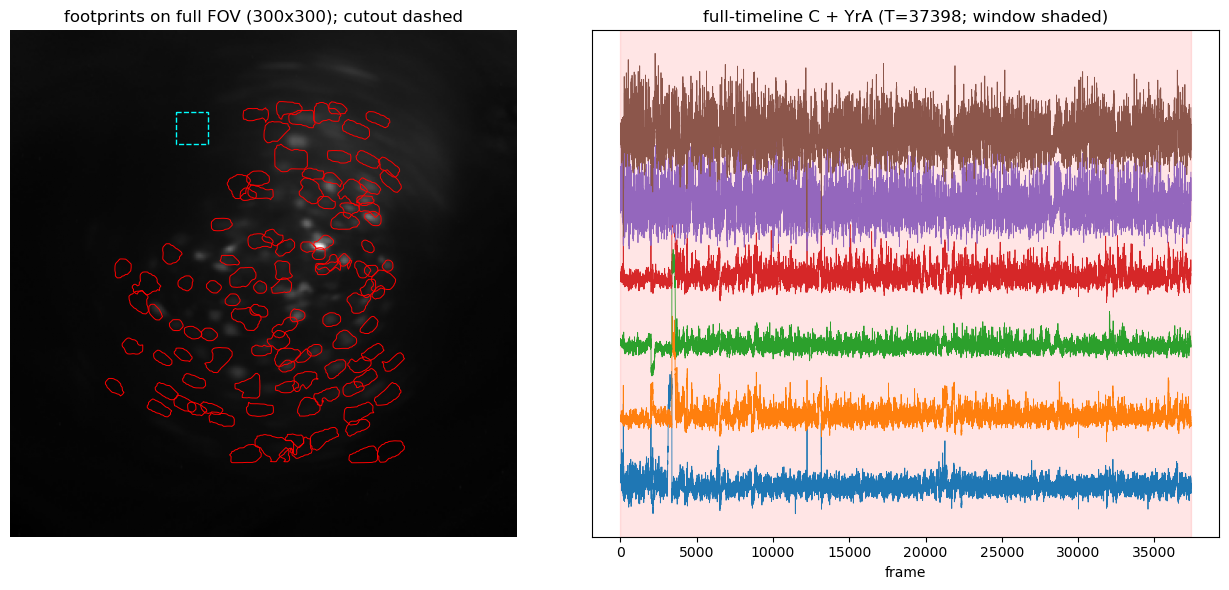

In [43]:
full = model.place_in_full_fov()    # footprints padded to full FOV; traces to full T
Kf = full.A.shape[1]
A_f = np.asarray(full.A.todense()).reshape(H, W, Kf)
accf = full.accepted_mask if full.accepted_mask is not None else np.ones(Kf, bool)
t0c, t1c = model.cutout['t_range']

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(mean_img, cmap='gray')
axes[0].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                ec='cyan', fc='none', lw=1.0, ls='--'))
for k in range(Kf):
    fp = A_f[..., k]
    if fp.max() <= 0:
        continue
    axes[0].contour(fp, [fp.max() * 0.3], colors='red' if accf[k] else '0.6', linewidths=0.7)
axes[0].set_title(f'footprints on full FOV ({H}x{W}); cutout dashed'); axes[0].axis('off')

proj = full.C + full.YrA            # (K, full T), zero outside the window
nn = min(6, Kf)
if nn:
    order = np.argsort(-proj.max(1))[:nn]
    step = float(proj.max()) * 0.6 or 1.0
    for j, k in enumerate(order):
        axes[1].plot(proj[k] + j * step, lw=0.6)
axes[1].axvspan(t0c, t1c, color='r', alpha=0.1)
axes[1].set_title(f'full-timeline C + YrA (T={proj.shape[1]}; window shaded)')
axes[1].set_xlabel('frame'); axes[1].set_yticks([])
plt.tight_layout(); plt.show()

## Summary / save

In [44]:
model.save(OUTPUT_DIR)
print(f'saved -> {OUTPUT_DIR}')
print('  manifest.json records the cutout (bbox, t_range, orig_dims, orig_T).')
if mask_path:
    print(f'  ROI mask: {mask_path}')
print('\nReload and map back to the full FOV/timeline anywhere:')
print('  from cnmfe.pipeline import CNMFe')
print(f"  m = CNMFe.load('{OUTPUT_DIR}')")
print('  full = m.place_in_full_fov()   # A on the original grid, C/YrA on the full T')

saved -> /home/fs539/code/simpler_cnmfe/tmp/cutout_analysis
  manifest.json records the cutout (bbox, t_range, orig_dims, orig_T).

Reload and map back to the full FOV/timeline anywhere:
  from cnmfe.pipeline import CNMFe
  m = CNMFe.load('/home/fs539/code/simpler_cnmfe/tmp/cutout_analysis')
  full = m.place_in_full_fov()   # A on the original grid, C/YrA on the full T


In [ ]:
print('hello')